# Parametric Drive T1 Analysis

This notebook reads and visualizes the parametric drive T1 data from the .h5 file.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Set plotting style
# plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)

In [5]:
from qcat.parser.qm_reader import load_xarray_h5, repetition_data
from qcat.utilities.simple_visualization import plot_2d_colormap_from_h5


In [15]:
# Define the path to the h5 file
h5_file_path = r"d:\github\ASQMDriver\data\2Q1C_17\2026-01-20\#836_LCH_qubit_parametric_drive_time_173702\ds_raw.h5"

# Check if file exists
if os.path.exists(h5_file_path):
    print(f"Found h5 file: {h5_file_path}")
else:
    print(f"File not found: {h5_file_path}")
    print(f"Current directory: {os.getcwd()}")
    print("Available files in current directory:")
    for file in os.listdir('.'):
        if file.endswith('.h5'):
            print(f"  - {file}")

Found h5 file: d:\github\ASQMDriver\data\2Q1C_17\2026-01-20\#836_LCH_qubit_parametric_drive_time_173702\ds_raw.h5


In [16]:
# Load data using the qcat parser
try:
    ds = load_xarray_h5(h5_file_path)
    print(f"Successfully loaded dataset with dimensions: {dict(ds.dims)}")
    print(f"Coordinates: {list(ds.coords.keys())}")
    print(f"Data variables: {list(ds.data_vars.keys())}")
    
    # Check if it has multiple qubits/repetitions
    if 'qubit' in ds.dims:
        print(f"\nFound {ds.sizes['qubit']} qubits in the dataset")
        qubit_data = repetition_data(ds, repetition_dim="qubit")
        print(f"Separated data into {len(qubit_data)} individual qubit datasets")
    else:
        qubit_data = [ds]  # Single dataset
        print("Single dataset (no qubit dimension)")
        
except Exception as e:
    print(f"Error loading file: {e}")
    ds = None

Successfully loaded dataset with dimensions: {'driving_time': 50, 'driving_frequency': 41, 'qubit': 1}
Coordinates: ['driving_time', 'driving_frequency', 'qubit']
Data variables: ['state1', 'state']

Found 1 qubits in the dataset
Separated data into 1 individual qubit datasets


C:\Users\shiau\AppData\Local\Temp\ipykernel_13936\4109142183.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Successfully loaded dataset with dimensions: {dict(ds.dims)}")


Creating heatmaps...

Processing qubit 0: q2
Available data variables: ['state1', 'state']
Available coordinates: ['driving_time', 'driving_frequency']
Plotting: state vs driving_time, driving_frequency


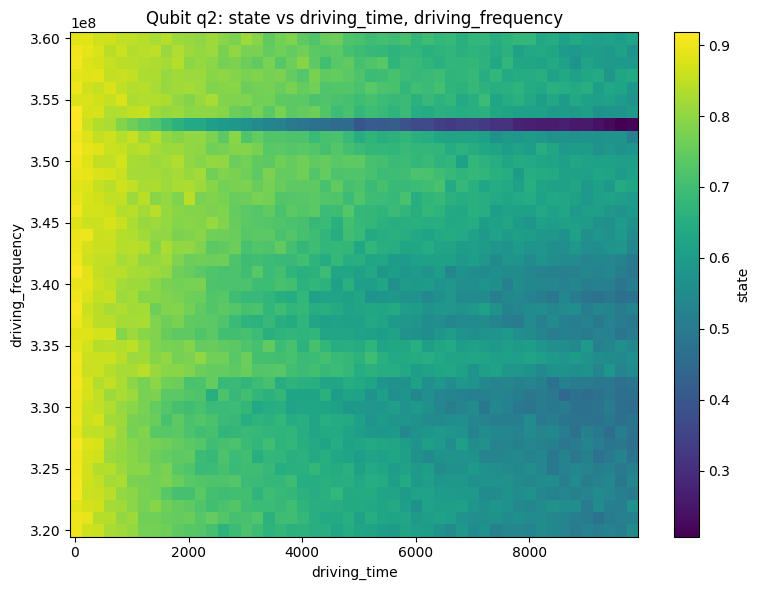


Heatmap creation complete!


In [17]:
# Analyze dataset structure and create heatmaps
if ds is not None and 'qubit_data' in locals():
    print("Creating heatmaps...")
    
    for i, sq_data in enumerate(qubit_data):
        try:
            qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
            print(f"\nProcessing qubit {i}: {qubit_name}")
        except:
            print(f"\nProcessing dataset {i}")
            
        # Get available data variables and coordinates
        data_vars = list(sq_data.data_vars.keys())
        coords = [c for c in sq_data.coords.keys() if c != 'qubit']  # Exclude qubit coordinate
        
        print(f"Available data variables: {data_vars}")
        print(f"Available coordinates: {coords}")
        
        # User-specified plotting parameters
        x_dim = "driving_time"
        y_dim = "driving_frequency"
        data_var = "state"  # Specify your data variable here
        
        print(f"Plotting: {data_var} vs {x_dim}, {y_dim}")
        fig = plot_2d_colormap_from_h5(sq_data, data_var, x_dim, y_dim)
        if fig:
            plt.show()
    
    print("\nHeatmap creation complete!")

Creating 1D line plots (state vs driving_frequency)...

Processing qubit 0: q2
Plotted time: 2016.0 ns (requested: 2000.0 ns)
Plotted time: 4016.0 ns (requested: 4000.0 ns)


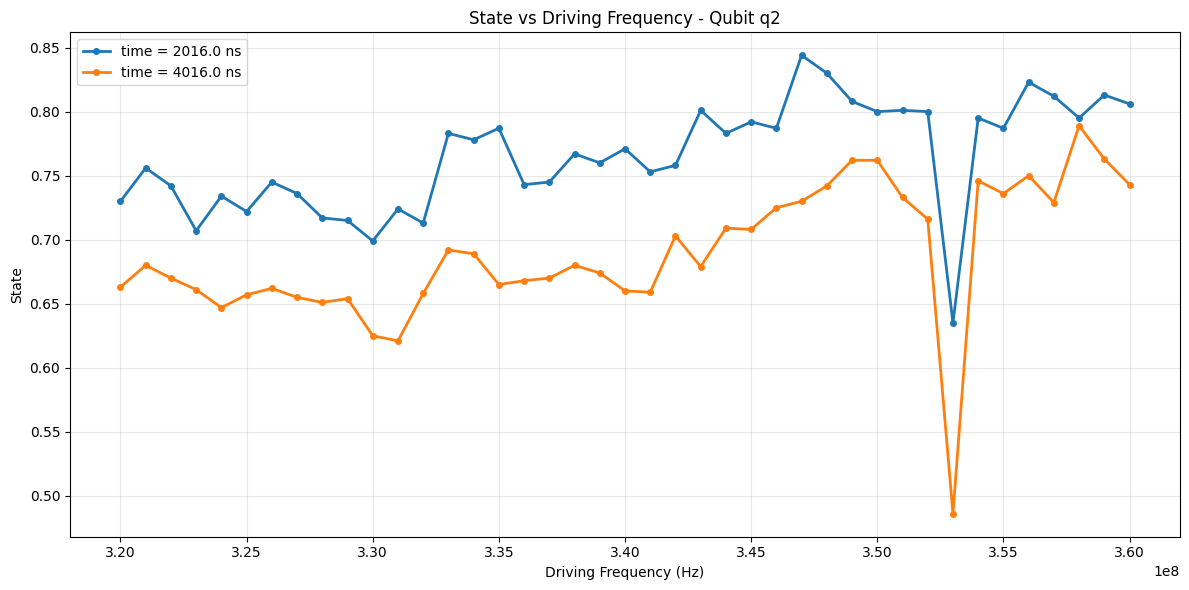


1D line plot (frequency sweep) creation complete!


In [18]:
# Plot 1D line graphs for specific driving times
if ds is not None and 'qubit_data' in locals():
    print("Creating 1D line plots (state vs driving_frequency)...")
    
    # User-specified driving times to plot
    target_times = [2000,4000]  # Modify this list as needed (in ns)
    
    for i, sq_data in enumerate(qubit_data):
        try:
            qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
            print(f"\nProcessing qubit {i}: {qubit_name}")
        except:
            print(f"\nProcessing dataset {i}")
        
        # Create figure for line plots
        plt.figure(figsize=(12, 6))
        
        # Get driving_time and driving_frequency arrays
        driving_time = sq_data.coords["driving_time"].values
        driving_freq = sq_data.coords["driving_frequency"].values
        
        # Plot line for each target time
        for time in target_times:
            # Find closest time in the data
            time_idx = np.argmin(np.abs(driving_time - time))
            actual_time = driving_time[time_idx]
            
            # Extract state data for this time
            state_data = sq_data["state"].isel(driving_time=time_idx).values
            
            # Plot the line
            plt.plot(driving_freq, state_data, 'o-', label=f'time = {actual_time:.1f} ns', linewidth=2, markersize=4)
            print(f"Plotted time: {actual_time:.1f} ns (requested: {time:.1f} ns)")
        
        # Format the plot
        plt.xlabel('Driving Frequency (Hz)')
        plt.ylabel('State')
        plt.title(f'State vs Driving Frequency - Qubit {qubit_name}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    print("\n1D line plot (frequency sweep) creation complete!")

Creating 1D line plots...

Processing qubit 0: q2
Plotted frequency: 353000000.000 GHz (requested: 353000000.000 GHz)
Plotted frequency: 350000000.000 GHz (requested: 350000000.000 GHz)


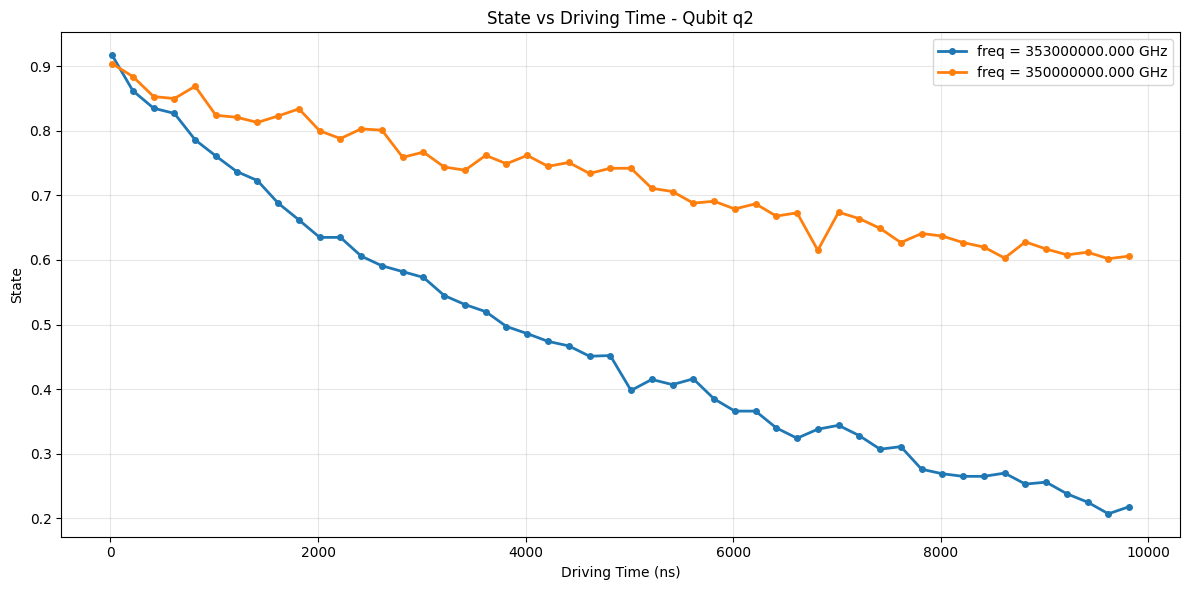


1D line plot creation complete!


In [19]:
# Plot 1D line graphs for specific driving frequencies
if ds is not None and 'qubit_data' in locals():
    print("Creating 1D line plots...")
    
    # User-specified driving frequencies to plot
    target_frequencies = [3.53e8, 3.5e8]  # Modify this list as needed
    
    for i, sq_data in enumerate(qubit_data):
        try:
            qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
            print(f"\nProcessing qubit {i}: {qubit_name}")
        except:
            print(f"\nProcessing dataset {i}")
        
        # Create figure for line plots
        plt.figure(figsize=(12, 6))
        
        # Get driving_time and driving_frequency arrays
        driving_time = sq_data.coords["driving_time"].values
        driving_freq = sq_data.coords["driving_frequency"].values
        
        # Plot line for each target frequency
        for freq in target_frequencies:
            # Find closest frequency in the data
            freq_idx = np.argmin(np.abs(driving_freq - freq))
            actual_freq = driving_freq[freq_idx]
            
            # Extract state data for this frequency
            state_data = sq_data["state"].isel(driving_frequency=freq_idx).values
            
            # Plot the line
            plt.plot(driving_time, state_data, 'o-', label=f'freq = {actual_freq:.3f} GHz', linewidth=2, markersize=4)
            print(f"Plotted frequency: {actual_freq:.3f} GHz (requested: {freq:.3f} GHz)")
        
        # Format the plot
        plt.xlabel('Driving Time (ns)')
        plt.ylabel('State')
        plt.title(f'State vs Driving Time - Qubit {qubit_name}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    print("\n1D line plot creation complete!")

Performing T1 exponential decay fitting...

Analyzing qubit 0: q1
Frequency: 0.500 GHz
  T1 (τ): 143.6 ns
  Amplitude: 0.9540
  Offset: 0.0375
  R²: 0.9823
Frequency: 1.000 GHz
  T1 (τ): 86.7 ns
  Amplitude: 1.0472
  Offset: 0.0253
  R²: 0.9974


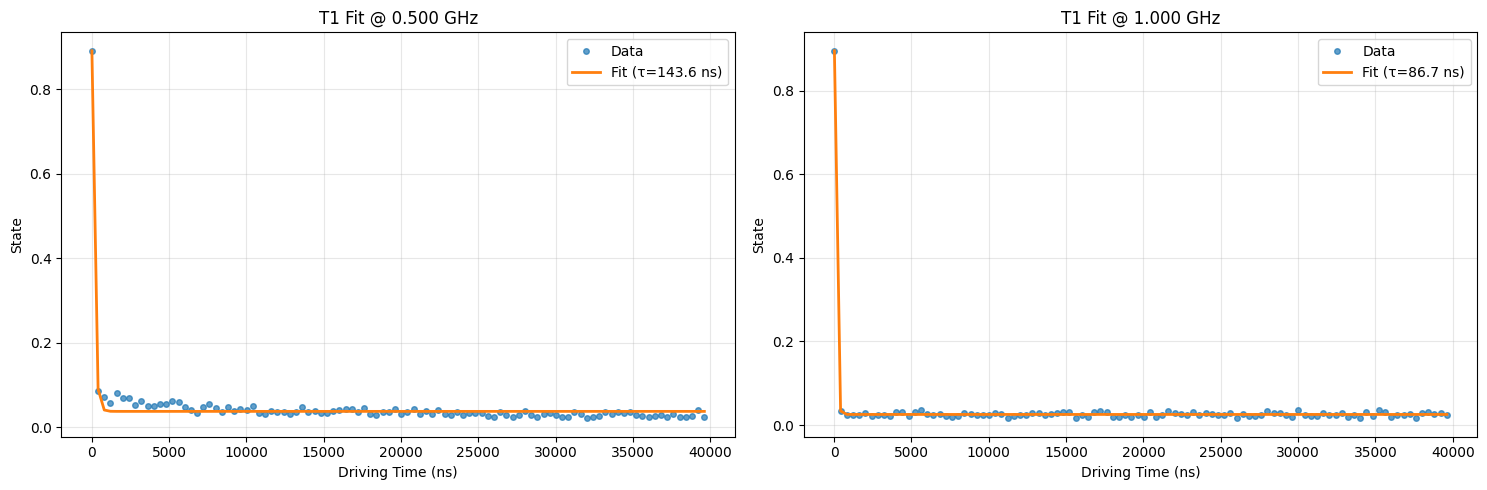


T1 Summary for Qubit q1:
Frequency (GHz) | T1 (ns) | R²
-----------------------------------
      0.500 |   143.6 | 0.9823
      1.000 |    86.7 | 0.9974

T1 fitting analysis complete!


In [14]:
# T1 fitting using exponential decay
import xarray as xr
from qcat.utilities.function_fitting.fit_exp_decay import FitExponentialDecay

if ds is not None and 'qubit_data' in locals():
    print("Performing T1 exponential decay fitting...")
    
    # User-specified driving frequencies for T1 analysis
    target_frequencies = [0.5e8, 1e8]  # Modify this list as needed
    
    for i, sq_data in enumerate(qubit_data):
        try:
            qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
            print(f"\nAnalyzing qubit {i}: {qubit_name}")
        except:
            print(f"\nAnalyzing dataset {i}")
        
        # Get driving_time and driving_frequency arrays
        driving_time = sq_data.coords["driving_time"].values
        driving_freq = sq_data.coords["driving_frequency"].values
        
        # Create subplot for fitted curves
        plt.figure(figsize=(15, 5))
        
        # Results storage
        fit_results = []
        
        # Fit exponential decay for each target frequency
        for j, freq in enumerate(target_frequencies):
            plt.subplot(1, len(target_frequencies), j+1)
            
            # Find closest frequency in the data
            freq_idx = np.argmin(np.abs(driving_freq - freq))
            actual_freq = driving_freq[freq_idx]
            
            # Extract state data for this frequency
            state_data = sq_data["state"].isel(driving_frequency=freq_idx).values
            
            # Create DataArray for fitting (fitter expects "x" coordinate)
            fit_data = xr.DataArray(
                state_data,
                coords={"x": driving_time},
                dims=["x"]
            )
            
            # Perform fitting
            fitter = FitExponentialDecay(fit_data)
            result = fitter.fit()
            
            # Extract fitted parameters
            a = result.params['a'].value
            tau = result.params['tau'].value
            c = result.params['c'].value
            
            # Store results
            fit_results.append({
                'frequency': actual_freq,
                'amplitude': a,
                'tau': tau,
                'offset': c,
                'r_squared': 1 - result.residual.var() / np.var(state_data)
            })
            
            # Plot data and fit
            plt.plot(driving_time, state_data, 'o', alpha=0.7, label='Data', markersize=4)
            plt.plot(driving_time, result.best_fit, '-', linewidth=2, label=f'Fit (τ={tau:.1f} ns)')
            
            plt.xlabel('Driving Time (ns)')
            plt.ylabel('State')
            plt.title(f'T1 Fit @ {actual_freq/1e8:.3f} GHz')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            print(f"Frequency: {actual_freq/1e8:.3f} GHz")
            print(f"  T1 (τ): {tau:.1f} ns")
            print(f"  Amplitude: {a:.4f}")
            print(f"  Offset: {c:.4f}")
            print(f"  R²: {1 - result.residual.var() / np.var(state_data):.4f}")
        
        plt.tight_layout()
        plt.show()
        
        # Summary table
        print(f"\nT1 Summary for Qubit {qubit_name}:")
        print("Frequency (GHz) | T1 (ns) | R²")
        print("-" * 35)
        for res in fit_results:
            print(f"{res['frequency']/1e8:11.3f} | {res['tau']:7.1f} | {res['r_squared']:.4f}")
    
    print("\nT1 fitting analysis complete!")